In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import sys
from copy import deepcopy,copy
from datetime import datetime
import pickle
import sys
import matplotlib.pyplot as plt
import warnings
from scipy.signal import savgol_filter
#warnings.filterwarnings("ignore")
#warnings.filterwarnings("ignore", category=RuntimeWarning)
stderr_fileno = sys.stderr
sys.stderr = open(os.devnull, 'w')

src = os.path.dirname('/export/home/oriolca/Integral_BMS_Governing_Equations/I-BMS/')
sys.path.append(src)
from mcmc_ode import *
from parallel_ode import *

path = os.path.join(src, "Prior/")
sys.path.append(path)
from fit_prior import read_prior_par

priors = {
    "v1_p8": f"Prior/final_prior_param_sq.named_equations.nv1.np8.2017-10-18 18:07:35.261518.dat",
    "v2_p3": f"Prior/final_prior_param_sq.named_equations.nv2.np3.2016-09-09 18:49:42.927679.dat",
    "v2_p4": f"Prior/final_prior_param_sq.named_equations.nv2.np4.2016-09-09 18:49:43.056910.dat",
    "v2_p8": f"Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat",
}

data=pd.read_pickle('../Logistic/noise_data/0.01_0.pkl')

print(data)

x = data[['B']]
t = pd.Series(data[['t']].t)

dt = t.to_numpy()[1] - t.to_numpy()[0]
window_length = 21    # must be odd and <= len(t)
polyorder = 2         # generally 2..5

x_hat = savgol_filter(x['B'], window_length, polyorder, delta=dt, mode='interp')

x_dot = savgol_filter(x['B'], window_length, polyorder, deriv=1, delta=dt, mode='interp')

dx = [pd.DataFrame(data = {'B': x_hat}), pd.DataFrame(data = {'B': x_dot})]

print(x)

print(t)

print(dx)

            B    t
0    0.006303 -6.0
1   -0.020679 -5.9
2    0.007921 -5.8
3   -0.013012 -5.7
4    0.007589 -5.6
..        ...  ...
115  1.012317  5.5
116  1.001676  5.6
117  1.000779  5.7
118  1.004363  5.8
119  0.996912  5.9

[120 rows x 2 columns]
            B
0    0.006303
1   -0.020679
2    0.007921
3   -0.013012
4    0.007589
..        ...
115  1.012317
116  1.001676
117  1.000779
118  1.004363
119  0.996912

[120 rows x 1 columns]
0     -6.0
1     -5.9
2     -5.8
3     -5.7
4     -5.6
      ... 
115    5.5
116    5.6
117    5.7
118    5.8
119    5.9
Name: t, Length: 120, dtype: float64
[            B
0   -0.006128
1   -0.003431
2   -0.000913
3    0.001425
4    0.003584
..        ...
115  0.998973
116  1.000340
117  1.001760
118  1.003234
119  1.004762

[120 rows x 1 columns],             B
0    0.027863
1    0.026071
2    0.024280
3    0.022488
4    0.020696
..        ...
115  0.013397
116  0.013935
117  0.014472
118  0.015010
119  0.015547

[120 rows x 1 columns]]


In [2]:
XLABS = ['B']
n_params = 8

path = os.path.join(src, priors[f"v{len(XLABS)}_p{str(n_params)}"])
prior_par = read_prior_par(path)

del prior_par['Nopi_abs']
del prior_par['Nopi2_abs']
del prior_par['Nopi_tan']
del prior_par['Nopi2_tan']
del prior_par['Nopi_sinh']
del prior_par['Nopi2_sinh']
del prior_par['Nopi_cosh']
del prior_par['Nopi2_cosh']
del prior_par['Nopi_tanh']
del prior_par['Nopi2_tanh']


OPS = {
    "sin": 1,
    "cos": 1,
    "exp": 1,
    "pow2": 1,
    "pow3": 1,
    "-": 1,
    "+": 2,
    "*": 2,
    "/": 2,
    "**": 2,
}
import time

start = time.time()
model_x = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string = "((_a0_ * B) + (_a1_ * (B ** 2)))"
)

print(model_x)
print(model_x.E)
print(model_x.par_values)
print(model_x.x0_values)

((_a0_ * B) + (_a1_ * (B ** 2)))
<SharedNumber -351.1822951701085>
<SharedDict {'d0': {'_a0_': 0.9951924959102676, '_a1_': -0.9935939295501385, '_a2_': 1.0, '_a3_': 1.0, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0, '_a7_': 1.0}}>
<SharedDict {'d0': array([0.00252376])}>


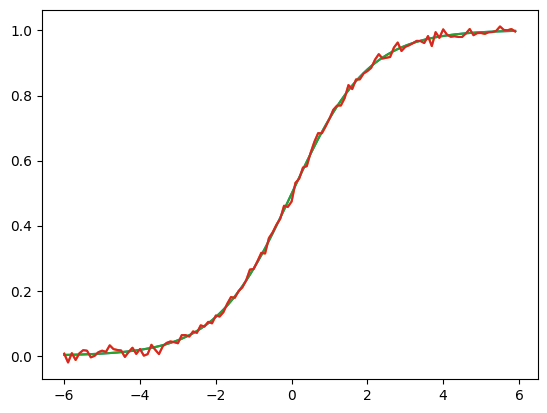

In [3]:
integral = model_x.integrate(t)

plt.plot(t,integral['d0']['B'])
plt.plot(t,x['B'])
plt.plot(t,integral['d0']['B'])
plt.plot(t,x['B'])

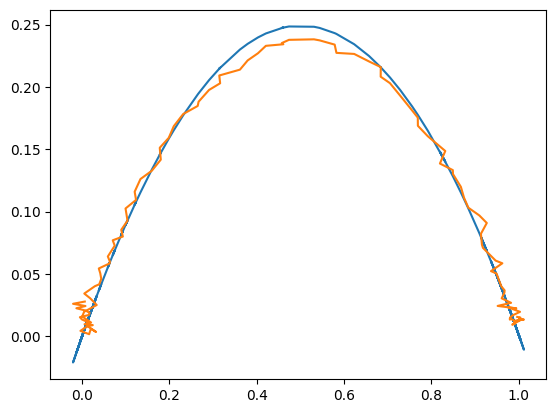

In [6]:
dx_pred = model_x.predict(x)

plt.plot(x['B'],dx_pred['B'])
plt.plot(x['B'],dx[1]['B'])